# 🟤 Copper Spot Price Forecasting — 1-Day Horizon

**1-day-ahead forecast: run today to get tomorrow's copper price prediction**

This notebook is a variant of `copper_forecast.ipynb` configured for next-day forecasting.
It trains all models, selects the best by out-of-sample Sharpe ratio, and prints
a forecast for the next trading day with an 80% confidence interval.

All other sections (data ingestion, feature engineering, model zoo, CV, backtesting,
SHAP explainability, scenario analysis) are identical to the main notebook.


## 1. Setup & Configuration


In [1]:
import os
import sys
import warnings
import logging
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from src.data_ingestion import load_data
from src.feature_engineering import build_features, split_features_targets
from src.models import NaiveModel, LinearModel, XGBoostModel, LGBMModel, EnsembleModel, QuantileForecaster
from src.models_arimax import ARIMAXModel
from src.models_hybrid import HybridModel
from src.models_stacking import StackingEnsemble
from src.evaluation import compute_metrics, walk_forward_cv, compare_models, out_of_sample_backtest
from src.visualization import (
    plot_price_history, plot_feature_correlations, plot_cv_results,
    plot_forecast_with_ci, plot_model_comparison, plot_shap_summary,
    plot_scenario_tornado, plot_dashboard, plot_regime_overlay,
)
from src.scenario_analysis import ScenarioEngine, SCENARIO_TEMPLATES
from src.cointegration import add_cointegration_features
from src.regime_detection import RegimeDetector
from src.feature_pruning import auto_prune_features

# Prophet is optional (heavy dependency)
try:
    from src.models_prophet import ProphetModel
    HAS_PROPHET = True
    print('✅ Prophet available')
except ImportError:
    HAS_PROPHET = False
    print('⚠️  Prophet not installed — ProphetModel will be skipped')

print('✅ All imports OK')

✅ Prophet available
✅ All imports OK


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────────────────
from src.config import load_config as _load_config
_cfg = _load_config('config.yaml')

CFG = {
    'start_date':        _cfg.get('data', {}).get('start_date', '2010-01-01'),
    'forecast_horizon':  1,               # 1-day ahead (next trading day)
    'all_horizons':      [1, 5, 22, 66],  # still engineer multi-horizon features
    'lags':              [1, 5, 22],      # look-back periods
    'initial_train_size': 504,            # ~2 years
    'cv_step_size':       5,              # re-fit weekly (finer than monthly for daily pred)
    'holdout_size':       252,            # ~1 year OOS backtest
    'ci_alpha':           0.80,           # confidence interval width
    'optuna_trials':      30,             # reduced for speed (set to 0 to skip)
    'fred_api_key':       os.environ.get('FRED_API_KEY') or _cfg.get('fred', {}).get('api_key'),
    'nasdaq_api_key':     os.environ.get('NASDAQ_DATA_LINK_API_KEY'),
    'alpha_vantage_api_key': os.environ.get('ALPHA_VANTAGE_API_KEY') or _cfg.get('alpha_vantage', {}).get('api_key'),
    'eia_api_key':        os.environ.get('EIA_API_KEY') or _cfg.get('eia', {}).get('api_key'),
    'random_seed':        42,
    'output_dir':         './outputs_1d',
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Configuration:', CFG)


Configuration: {'start_date': '2015-01-01', 'forecast_horizon': 1, 'all_horizons': [1, 5, 22, 66], 'lags': [1, 5, 22], 'initial_train_size': 504, 'cv_step_size': 5, 'holdout_size': 252, 'ci_alpha': 0.8, 'optuna_trials': 30, 'fred_api_key': 'eaee687cdf5188418e1b90c42a6a7ab5', 'nasdaq_api_key': None, 'alpha_vantage_api_key': 'VTGT0RZTXKB41YMF', 'eia_api_key': '55wZufZB7ZgMqET3LmZhcQVUzjri2ruBbCy97UBT', 'random_seed': 42, 'output_dir': './outputs_1d'}


## 2. Data Ingestion

Data is downloaded from three sources:
- **yfinance**: Copper (HG=F), DXY, Gold, Aluminium, Oil, CNY/USD, S&P 500, Shanghai
- **FRED API**: Industrial production, real yields, inflation breakeven, M2
- **CFTC COT**: Commercial/non-commercial positioning, open interest, speculative ratio

If no API keys are available, synthetic placeholder series are used (safe for testing).

In [3]:
df_raw = load_data(
    start=CFG['start_date'],
    fred_api_key=CFG['fred_api_key'],
    include_cot=True,
    nasdaq_api_key=CFG['nasdaq_api_key'],
    alpha_vantage_api_key=CFG['alpha_vantage_api_key'],
    eia_api_key=CFG['eia_api_key'],
)
print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min().date()} → {df_raw.index.max().date()}')
print(f'\nColumns: {list(df_raw.columns)}')
df_raw.tail()


ERROR | $ARCH: possibly delisted; no timezone found
ERROR | $NILSY: possibly delisted; no timezone found
ERROR | $X: possibly delisted; no timezone found
ERROR | $GOGL: possibly delisted; no timezone found
ERROR | 
4 Failed downloads:
ERROR | ['ARCH', 'NILSY', 'X', 'GOGL']: possibly delisted; no timezone found
INFO | yfinance: downloaded 2930 rows for 105 tickers
INFO | FRED: fetched INDPRO (134 obs)
INFO | FRED: fetched IPMAN (134 obs)
INFO | FRED: fetched TCU (134 obs)
WARNING | FRED: could not fetch MCUMFNS — Bad Request.  The series does not exist.
INFO | FRED: fetched HOUST (133 obs)
INFO | FRED: fetched PERMIT (133 obs)
INFO | FRED: fetched TTLCONS (133 obs)
INFO | FRED: fetched TLRESCONS (133 obs)
INFO | FRED: fetched MANEMP (135 obs)
INFO | FRED: fetched AMTMNO (133 obs)
INFO | FRED: fetched AMTMUO (133 obs)
INFO | FRED: fetched DGORDER (133 obs)
INFO | FRED: fetched TOTALSA (135 obs)
INFO | FRED: fetched FEDFUNDS (135 obs)
INFO | FRED: fetched M2SL (134 obs)
INFO | FRED: fetch

Dataset shape: (2929, 152)
Date range: 2015-01-02 → 2026-04-02

Columns: ['shanghai', 'alcoa', 'agnico', 'aluminium', 'coal_amr', 'antofagasta', 'coal_arch', 'aud_usd', 'dry_bulk_etf', 'bhp', 'coal_btu', 'oil_brent', 'caterpillar', 'oil_wti', 'cleveland_cliffs', 'copper_miners_etf', 'copper_etf', 'base_metals_etf', 'commodity_idx', 'diana_shipping', 'dxy', 'em_etf', 'eagle_bulk', 'ero_copper', 'eur_usd', 'fcx', 'first_quantum', 'franco_nevada', 'china_etf', 'gbp_usd', 'gold', 'gold_miners_etf', 'glencore', 'genco', 'golden_ocean', 'gsci_etf', 'copper_price', 'heating_oil', 'clean_energy_etf', 'latam_etf', 'ivanhoe', 'kinross', 'lumber', 'lithium_etf', 'lundin', 'matson', 'arcelormittal', 'newmont', 'nat_gas', 'anglo_american', 'norilsk', 'nucor', 'nzd_usd', 'palladium', 'commodity_broad2', 'global_miners_etf', 'construction_etf', 'platinum', 'rare_earth', 'rio', 'safe_bulkers', 'star_bulk', 'scco', 'silver', 'silver_etf', 'steel_etf', 'solar_etf', 'teck', 'tesla', 'ternium', 'uranium_e

,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum,av_natural_gas,commercial_net,noncommercial_net,open_interest,spec_ratio
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-27,3913.724121,58.410000,193.399994,3187.50,223.259995,44.080002,NaN,0.688740,9.930,69.500000,...,2.99,NaN,NaN,NaN,NaN,3.05,20554.80242,-7555.542565,140867.844199,0.088011
2026-03-30,3923.287109,63.220001,191.860001,3336.25,214.240005,41.209999,NaN,0.685090,9.940,69.019997,...,2.88,NaN,NaN,NaN,NaN,3.05,20554.80242,-7555.542565,140867.844199,0.088011
2026-03-31,3891.861084,66.330002,202.979996,3405.50,205.270004,44.570000,NaN,0.684590,9.970,72.739998,...,2.88,NaN,NaN,NaN,NaN,3.05,20554.80242,-7555.542565,140867.844199,0.088011
2026-04-01,3948.552002,72.059998,210.080002,3452.25,198.330002,47.549999,NaN,0.692051,10.325,73.559998,...,2.88,NaN,NaN,NaN,NaN,3.05,20554.80242,-7555.542565,140867.844199,0.088011
2026-04-02,3919.284912,71.529999,208.539993,3411.00,209.309998,45.930000,NaN,0.692400,10.450,73.239998,...,2.88,NaN,NaN,NaN,NaN,3.05,20554.80242,-7555.542565,140867.844199,0.088011


In [4]:
# Summary statistics
df_raw.describe().round(2)


,shanghai,alcoa,agnico,aluminium,coal_amr,antofagasta,coal_arch,aud_usd,dry_bulk_etf,bhp,...,nat_gas_spot,copper_lme_monthly,china_mfg_prod,av_copper,av_aluminum,av_natural_gas,commercial_net,noncommercial_net,open_interest,spec_ratio
count,2921.00,2929.00,2929.00,2545.00,1339.00,2865.00,0.0,2929.00,2090.00,2929.00,...,2929.00,563.00,203.00,2910.00,2910.00,2929.00,2929.00,2929.00,2929.00,2929.00
mean,3245.48,33.13,56.01,2203.40,162.51,15.13,NaN,0.71,13.36,36.25,...,3.17,7365.61,1.10,7449.46,2135.87,3.17,10763.83,-5873.81,155707.75,0.12
std,367.64,13.53,36.53,436.26,91.26,9.09,NaN,0.05,7.28,15.32,...,1.64,1796.11,0.88,1922.17,440.25,1.38,5850.75,4634.41,8746.94,0.09
min,2464.36,5.23,17.45,1452.00,10.87,4.09,NaN,0.57,3.91,9.45,...,1.21,4471.79,-0.51,4471.79,1459.93,1.49,-3951.07,-15562.85,133495.54,-0.07
25%,3004.88,23.08,37.37,1820.25,115.74,8.61,NaN,0.67,7.72,22.08,...,2.39,5833.01,0.51,5833.01,1773.86,2.37,7463.63,-9636.09,148276.96,0.04
50%,3216.75,31.66,46.31,2203.00,156.11,11.58,NaN,0.71,10.69,33.27,...,2.82,6965.86,1.22,6851.51,2097.44,2.83,11295.97,-5814.86,157032.71,0.13
75%,3399.77,40.90,57.23,2487.50,212.06,19.46,NaN,0.75,18.92,50.30,...,3.24,8988.25,1.71,9075.73,2446.65,3.27,15282.81,-1971.49,163258.42,0.18
max,5166.35,90.95,252.19,3873.00,442.21,61.72,NaN,0.82,41.51,81.41,...,30.72,11790.96,3.66,12986.61,3498.37,8.81,21972.03,4307.65,172598.82,0.31


In [5]:
# Missing data audit
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
audit = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing data audit:')
print(audit[audit['missing_count'] > 0].to_string() if (audit['missing_count'] > 0).any() else 'No missing data')


Missing data audit:
                     missing_count  missing_pct
shanghai                         8          0.3
aluminium                      384         13.1
coal_amr                      1590         54.3
antofagasta                     64          2.2
coal_arch                     2929        100.0
dry_bulk_etf                   839         28.6
coal_btu                       586         20.0
copper_etf                       3          0.1
eagle_bulk                    2681         91.5
ero_copper                     746         25.5
golden_ocean                  2929        100.0
lumber                         743         25.4
anglo_american                  29          1.0
norilsk                       2929        100.0
platinum                         2          0.1
uranium_miners                1282         43.8
usd_cnh                       2929        100.0
usd_cny                          3          0.1
us_steel                      2929        100.0
zim                 

## 3. Exploratory Data Analysis

### 3.1 Copper price history


In [6]:
fig_price = plot_price_history(df_raw)
fig_price.show()


### 3.2 Correlation with copper price


In [7]:
# Pairwise correlations of all series with copper price
corr_all = df_raw.corr()['copper_price'].drop('copper_price').sort_values()
import plotly.express as px
fig_corr_bar = px.bar(
    x=corr_all.values, y=corr_all.index,
    orientation='h', title='Pearson Correlation with Copper Price',
    labels={'x': 'Pearson r', 'y': 'Series'},
    template='plotly_white',
    color=corr_all.values,
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
)
fig_corr_bar.show()


### 3.3 Return distribution


In [8]:
log_ret = np.log(df_raw['copper_price'] / df_raw['copper_price'].shift(1)).dropna()

import plotly.graph_objects as go
fig_dist = go.Figure()
fig_dist.add_trace(go.Histogram(
    x=log_ret, nbinsx=80, name='Daily log return',
    marker_color='#b87333', opacity=0.75,
))
fig_dist.update_layout(
    title='Distribution of Daily Copper Log Returns',
    xaxis_title='Log Return', yaxis_title='Count',
    template='plotly_white',
)
fig_dist.show()
print(f'Skewness: {log_ret.skew():.3f}  |  Kurtosis: {log_ret.kurt():.3f}')
print(f'Ann. volatility: {log_ret.std() * np.sqrt(252):.1%}')


Skewness: -1.503  |  Kurtosis: 29.040
Ann. volatility: 24.0%


## 4. Cointegration Analysis & Regime Detection

### 4.1 Cointegration tests

We test copper's long-run equilibrium relationships with gold, aluminium, oil, DXY, and CNY using the Engle-Granger two-step procedure. For cointegrated pairs, rolling error-correction terms (ECTs) are computed as features.

In [9]:
# Run cointegration tests and add ECT features
df_aug, coint_results = add_cointegration_features(df_raw)

# Display results
coint_df = pd.DataFrame(coint_results).T
print('── Cointegration Test Results (Engle-Granger) ──')
print(coint_df.to_string())
print(f'\nCointegrated pairs: {[k for k, v in coint_results.items() if v["is_cointegrated"]]}')
print(f'ECT columns added: {[c for c in df_aug.columns if c.startswith("ect_")]}')

INFO | Cointegration test: t=-2.144  p=0.4532  beta=2.1533  cointegrated=False
INFO | Cointegration test: t=-3.597  p=0.0247  beta=4.3130  cointegrated=True
INFO | Cointegration: added ect_aluminium (p=0.0247)
INFO | Cointegration: column 'oil' not in DataFrame, skipping
INFO | Cointegration test: t=-0.979  p=0.9068  beta=111.4490  cointegrated=False
INFO | Cointegration: column 'cny_usd' not in DataFrame, skipping


── Cointegration Test Results (Engle-Granger) ──
              column is_cointegrated   p_value        beta
gold            gold           False  0.453217    2.153277
aluminium  aluminium            True  0.024702       4.313
dxy              dxy           False  0.906791  111.449002

Cointegrated pairs: ['aluminium']
ECT columns added: ['ect_aluminium']


### 4.2 Regime detection (Hidden Markov Model)

A 3-state Gaussian HMM identifies latent market regimes from returns, volatility, and z-score. States are relabelled by ascending mean return: **0 = bear, 1 = sideways, 2 = bull**.

Regime labels are added as features (one-hot encoded) for the forecasting models.

In [10]:
# Build preliminary features for regime detection (needs returns, vol, zscore)
feats_prelim = build_features(df_aug, lags=CFG['lags'], horizons=CFG['all_horizons'])

# Fit regime detector on development data (exclude holdout)
n_holdout = CFG['holdout_size']
regime_detector = RegimeDetector(n_regimes=3)

try:
    regime_detector.fit(feats_prelim.iloc[:-n_holdout])
    regime_labels = regime_detector.predict(feats_prelim)
    print(f'Regime distribution:\n{regime_labels.value_counts().sort_index()}')
    
    # Plot regime overlay on copper price
    fig_regime = plot_regime_overlay(df_aug['copper_price'], regime_labels)
    fig_regime.show()
except ImportError:
    print('⚠️  hmmlearn not installed — regime detection skipped')
    regime_labels = None
except Exception as e:
    print(f'⚠️  Regime detection failed: {e}')
    regime_labels = None

INFO | RegimeDetector: fitted 3 regimes on 2478 observations (3 features)


Regime distribution:
0.0     354
1.0    1029
2.0    1347
Name: count, dtype: int64


## 5. Feature Engineering

Features are built in five groups:

| Group | Features |
|---|---|
| **Price-derived** | Log returns (1/5/22d), realised vol, z-score vs 200-day MA, RSI-14, MACD, Bollinger width |
| **Cross-asset** | Gold/copper ratio, oil/copper ratio, Al–Cu spread %, DXY level & return, CNY/USD, S&P 500 |
| **Macro/calendar** | IP YoY, real yield, inflation breakeven, month sin/cos, CNY flag, quarter-end, US holidays, options expiry |
| **COT positioning** | Commercial net, non-commercial net, open interest, speculative ratio |
| **Structural** | Cointegration ECTs (rolling), HMM regime dummies |

Each base feature is lagged at 1, 5, and 22 days to preserve causality.

In [11]:
feats = build_features(
    df_aug,
    lags=CFG['lags'],
    horizons=CFG['all_horizons'],
)

# Add regime features if available
if regime_labels is not None:
    feats['regime'] = regime_labels.reindex(feats.index)
    for i in range(3):
        feats[f'regime_{i}'] = (feats['regime'] == i).astype(float)

print(f'Feature matrix shape: {feats.shape}')
feat_cols = [c for c in feats.columns if not c.startswith('target_') and c != 'copper_price']
print(f'Number of features (pre-lag): {len([c for c in feat_cols if "_lag_" not in c])}')
print(f'Total features (incl. lags): {len(feat_cols)}')

Feature matrix shape: (2929, 137)
Number of features (pre-lag): 35
Total features (incl. lags): 128


In [12]:
X, y_ret, y_price = split_features_targets(feats, horizon=CFG['forecast_horizon'])
print(f'X: {X.shape}  |  y: {y_ret.shape}')
print(f'Date range: {X.index.min().date()} → {X.index.max().date()}')


X: (2209, 124)  |  y: (2209,)
Date range: 2015-11-09 → 2026-04-01


In [13]:
# Feature–target correlation chart (top 25 features)
fig_feat_corr = plot_feature_correlations(X, y_ret, top_n=25)
fig_feat_corr.show()


## 6. Model Training & Hyper-parameter Tuning

### Models built
1. **Naive** — random-walk baseline (always predicts 0 return)
2. **Ridge** — linear benchmark with standard scaling
3. **XGBoost** — gradient-boosted trees (Optuna-tuned)
4. **LightGBM** — fast gradient boosting (Optuna-tuned)
5. **ARIMAX** — econometric model with macro exogenous features
6. **Prophet** — Bayesian structural time series (optional)
7. **Hybrid** — ARIMAX backbone + LightGBM residual correction
8. **Weighted Ensemble** — equal-weight average of XGBoost + LightGBM
9. **Stacking Ensemble** — meta-learner (Ridge) on walk-forward OOF predictions

Tuning uses `TimeSeriesSplit` cross-validation to prevent look-ahead.

In [14]:
naive   = NaiveModel()
linear  = LinearModel()
xgb_mdl = XGBoostModel()
lgb_mdl = LGBMModel()

# For 1-day forecasting use shorter-window vol and 1-day macro features
arimax  = ARIMAXModel(exog_cols=[
    'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
])
hybrid  = HybridModel(backbone=ARIMAXModel(exog_cols=[
    'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
]))

if HAS_PROPHET:
    prophet_mdl = ProphetModel(regressor_cols=[
        'dxy_level', 'real_yield_level', 'gold_copper_ratio', 'copper_vol_5d'
    ])

# Split off the final holdout before any tuning
n_holdout = CFG['holdout_size']
X_dev, y_dev = X.iloc[:-n_holdout], y_ret.iloc[:-n_holdout]
X_hold, y_hold = X.iloc[-n_holdout:], y_ret.iloc[-n_holdout:]
price_hold = y_price.iloc[-n_holdout:]

print(f'Development set: {len(X_dev)} rows')
print(f'Holdout set:     {len(X_hold)} rows')


Development set: 1957 rows
Holdout set:     252 rows


In [15]:
# ── Optuna tuning (set optuna_trials=0 to skip) ──────────────────────────
import time

if CFG['optuna_trials'] > 0:
    print('Tuning XGBoost...')
    t0 = time.time()
    best_xgb = xgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_xgb}')

    print('Tuning LightGBM...')
    t0 = time.time()
    best_lgb = lgb_mdl.tune(X_dev, y_dev, n_trials=CFG['optuna_trials'])
    print(f'  Done in {time.time()-t0:.1f}s | best params: {best_lgb}')
else:
    print('Skipping Optuna tuning (optuna_trials=0). Using default params.')


Tuning XGBoost...


INFO | XGBoost best CV RMSE: 0.014436 | params: {'n_estimators': 768, 'learning_rate': 0.0010322851929145003, 'max_depth': 5, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.7102020040921988, 'min_child_weight': 5, 'reg_alpha': 7.156218227968665, 'reg_lambda': 0.2414692864254169, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


  Done in 333.4s | best params: {'n_estimators': 768, 'learning_rate': 0.0010322851929145003, 'max_depth': 5, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.7102020040921988, 'min_child_weight': 5, 'reg_alpha': 7.156218227968665, 'reg_lambda': 0.2414692864254169, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
Tuning LightGBM...


INFO | LGBM best CV RMSE: 0.014436 | params: {'n_estimators': 509, 'learning_rate': 0.023076168040117313, 'num_leaves': 23, 'max_depth': 7, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.5325257964926398, 'reg_alpha': 5.5517216852447255, 'reg_lambda': 6.732248920775331, 'min_child_samples': 42, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


  Done in 58.3s | best params: {'n_estimators': 509, 'learning_rate': 0.023076168040117313, 'num_leaves': 23, 'max_depth': 7, 'subsample': 0.6682096494749166, 'colsample_bytree': 0.5325257964926398, 'reg_alpha': 5.5517216852447255, 'reg_lambda': 6.732248920775331, 'min_child_samples': 42, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [16]:
# Weighted ensemble of the two gradient-boosting models
w_ensemble = EnsembleModel([xgb_mdl, lgb_mdl])

# Fit all base models on the development set
base_models = [naive, linear, xgb_mdl, lgb_mdl, arimax, hybrid]
if HAS_PROPHET:
    base_models.append(prophet_mdl)
base_models.append(w_ensemble)

for m in base_models:
    m.fit(X_dev, y_dev)
    print(f'Fitted: {m.name}')

# Stacking ensemble (uses walk-forward OOF internally)
print('\nFitting stacking ensemble (this may take a few minutes)...')
stack_base = [XGBoostModel(), LGBMModel(), ARIMAXModel()]
if HAS_PROPHET:
    stack_base.append(ProphetModel())

stacking = StackingEnsemble(
    base_models=stack_base,
    oof_initial_size=CFG['initial_train_size'],
    oof_step=CFG['cv_step_size'],
)
stacking.fit(X_dev, y_dev)
print(f'Fitted: {stacking.name}')

Fitted: Naive (RW)
Fitted: Linear (Ridge)
Fitted: XGBoost
Fitted: LightGBM


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-11059.0)


Fitted: ARIMAX


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-11059.0)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=0.014228


Fitted: Hybrid(ARIMAX+LightGBM)


INFO | Prophet: fitted with 4 regressors on 1957 observations


Fitted: Prophet
Fitted: Ensemble(XGBoost+LightGBM)

Fitting stacking ensemble (this may take a few minutes)...


INFO | Stacking OOF: XGBoost produced 1453 predictions
INFO | Stacking OOF: LightGBM produced 1453 predictions
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2504.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2833.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2817.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2602.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2689.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2970.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3106.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3212.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3242.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3044.4)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3119.7)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3047.3)
INFO | ARIMAX

Fitted: Stacking(XGBoost+LightGBM+ARIMAX+Prophet)


## 7. Feature Pruning (SHAP-based)

Automatically remove features in the bottom 20% by mean |SHAP| importance. Retrain and compare performance before/after pruning.

In [17]:
# Auto-prune low-importance features using SHAP
try:
    prune_model = XGBoostModel()
    X_pruned, dropped, importance = auto_prune_features(
        prune_model, X_dev, y_dev, threshold='bottom_20pct'
    )
    print(f'Features before pruning: {X_dev.shape[1]}')
    print(f'Features after pruning:  {X_pruned.shape[1]}')
    print(f'Dropped {len(dropped)} features')
    print(f'\nTop 15 features by importance:')
    print(importance.head(15).to_string(index=False))

    # Update X, X_dev, X_hold with pruned features
    kept_cols = X_pruned.columns.tolist()
    X_dev_pruned = X_dev[kept_cols]
    X_hold_pruned = X_hold[kept_cols]
    X_pruned_full = X[kept_cols]
    USE_PRUNED = True
except Exception as e:
    print(f'Feature pruning skipped: {e}')
    X_dev_pruned = X_dev
    X_hold_pruned = X_hold
    X_pruned_full = X
    USE_PRUNED = False
    kept_cols = X_dev.columns.tolist()

INFO | Feature pruning: kept 99 / 124 features (dropped 25 below threshold 0.000055)


Features before pruning: 124
Features after pruning:  99
Dropped 25 features

Top 15 features by importance:
                     feature  mean_abs_shap
         copper_ret_1d_lag_1       0.000919
  real_yield_change_5d_lag_5       0.000777
         copper_ret_1d_lag_5       0.000665
               copper_ret_1d       0.000652
                sp500_ret_5d       0.000647
        copper_vol_5d_lag_22       0.000636
         copper_ret_5d_lag_1       0.000634
        sp500_ret_22d_lag_22       0.000619
                      rsi_14       0.000591
             bb_width_lag_22       0.000523
            dxy_ret_1d_lag_1       0.000518
            dxy_ret_5d_lag_1       0.000501
           dxy_ret_5d_lag_22       0.000476
           gold_copper_ratio       0.000453
real_yield_change_22d_lag_22       0.000444


## 8. Walk-Forward Cross-Validation

Expanding-window validation simulates live deployment:
- **Initial window**: 504 trading days (~2 years)
- **Step size**: 22 days (model re-fitted monthly)
- All predictions are strictly out-of-sample for their training window
- Metrics include **signal Sharpe** for trading signal quality

In [18]:
# Re-instantiate all models fresh for CV (using pruned features)
cv_models = [
    NaiveModel(), LinearModel(), XGBoostModel(), LGBMModel(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([XGBoostModel(), LGBMModel()]),
]
if HAS_PROPHET:
    cv_models.append(ProphetModel())

print('Running walk-forward CV...')
summary, cv_results = compare_models(
    cv_models, X_dev_pruned, y_dev,
    initial_train_size=CFG['initial_train_size'],
    step_size=CFG['cv_step_size'],
    horizon=CFG['forecast_horizon'],
)
print('\n── Walk-Forward CV Metrics ──')
print(summary.to_string())

INFO | Evaluating model: Naive (RW)


Running walk-forward CV...


INFO | [Naive (RW)] RMSE=0.0149  MAE=0.0110  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | Evaluating model: Linear (Ridge)
INFO | [Linear (Ridge)] RMSE=0.0160  MAE=0.0121  MAPE=187.05%  DA=50.47%  Sharpe=0.31
INFO | Evaluating model: XGBoost
INFO | [XGBoost] RMSE=0.0156  MAE=0.0117  MAPE=169.69%  DA=48.67%  Sharpe=-0.60
INFO | Evaluating model: LightGBM
INFO | [LightGBM] RMSE=0.0155  MAE=0.0117  MAPE=159.08%  DA=50.68%  Sharpe=-0.13
INFO | Evaluating model: ARIMAX
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2504.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2833.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2817.6)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2602.3)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2689.1)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-2970.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-3106.2)
INFO | ARIMAX: fitted 


── Walk-Forward CV Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
model                                                                                                                       
Naive (RW)                  1.492237e-02  1.104154e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              1.599443e-02  1.208164e-02  1.870484e+02              0.504659       0.311527           0.311527
XGBoost                     1.555316e-02  1.167956e-02  1.696851e+02              0.486738      -0.604273          -0.604273
LightGBM                    1.551066e-02  1.167649e-02  1.590803e+02              0.506810      -0.132809          -0.132809
ARIMAX                      1.232586e+06  4.477878e+04  5.963340e+08              0.531183       0.663498           0.663498
Hybrid(ARIMAX+LightGBM)     3.184074e+37  1.251334e+37  3.859956e+41              0.488889    

In [19]:
# Visualise model comparison
fig_cmp = plot_model_comparison(summary, metric='rmse')
fig_cmp.show()


In [20]:
fig_cmp_da = plot_model_comparison(summary, metric='directional_accuracy',
                                    title='Model Comparison — Directional Accuracy')
fig_cmp_da.show()


In [21]:
# Best model CV predictions vs actuals
best_name = summary['rmse'].idxmin()
print(f'Best model by CV RMSE: {best_name}')
fig_cv = plot_cv_results(cv_results[best_name], model_name=best_name)
fig_cv.show()


Best model by CV RMSE: Naive (RW)


## 9. Out-of-Sample Backtesting

Train on all development data; evaluate on the last ~252 trading days (one year).
This mimics a realistic forward-test scenario.

In [22]:
oos_results = {}
oos_metrics = {}

# Re-instantiate and fit all models on pruned dev data for OOS test
oos_model_list = [
    NaiveModel(), LinearModel(), XGBoostModel(), LGBMModel(),
    ARIMAXModel(), HybridModel(),
    EnsembleModel([XGBoostModel(), LGBMModel()]),
]
if HAS_PROPHET:
    oos_model_list.append(ProphetModel())

for m in oos_model_list:
    m.fit(X_dev_pruned, y_dev)
    oos_df, met = out_of_sample_backtest(
        m, X_pruned_full, y_ret,
        holdout_size=n_holdout,
        horizon=CFG['forecast_horizon'],
    )
    oos_results[m.name] = oos_df
    oos_metrics[m.name] = met

oos_summary = pd.DataFrame(oos_metrics).T
print('── Out-of-Sample Backtest Metrics ──')
print(oos_summary.to_string())

INFO | [Naive (RW) OOS] RMSE=0.0247  MAE=0.0142  MAPE=100.00%  DA=0.00%  Sharpe=0.00
INFO | [Linear (Ridge) OOS] RMSE=0.0252  MAE=0.0152  MAPE=199.36%  DA=48.98%  Sharpe=0.41
INFO | [XGBoost OOS] RMSE=0.0250  MAE=0.0149  MAPE=173.40%  DA=52.24%  Sharpe=1.50
INFO | [LightGBM OOS] RMSE=0.0257  MAE=0.0157  MAPE=196.07%  DA=48.57%  Sharpe=-0.02
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-10824.2)
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-10824.2)
INFO | [ARIMAX OOS] RMSE=592.5384  MAE=219.2900  MAPE=3561643.32%  DA=53.06%  Sharpe=1.40
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-10824.2)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=1768661053509059721247756407856731269600641024.000000
INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-10824.2)
INFO | Hybrid: backbone=ARIMAX  residual_model=LightGBM  residual_std=1768661053509059721247756407856731269600641024.000000
INFO | [Hybrid(ARIMAX+L

── Out-of-Sample Backtest Metrics ──
                                    rmse           mae          mape  directional_accuracy  signal_sharpe  information_ratio
Naive (RW)                  2.467419e-02  1.418595e-02  1.000000e+02              0.000000       0.000000           0.000000
Linear (Ridge)              2.516961e-02  1.522765e-02  1.993562e+02              0.489796       0.413371           0.413371
XGBoost                     2.501769e-02  1.494837e-02  1.733954e+02              0.522449       1.496758           1.496758
LightGBM                    2.567521e-02  1.565105e-02  1.960692e+02              0.485714      -0.024067          -0.024067
ARIMAX                      5.925384e+02  2.192900e+02  3.561643e+06              0.530612       1.397994           1.397994
Hybrid(ARIMAX+LightGBM)     3.012150e+37  2.344468e+37  5.971908e+41              0.538776       1.745159           1.745159
Ensemble(XGBoost+LightGBM)  2.528714e-02  1.523649e-02  1.810137e+02              0.5102

In [23]:
# OOS actual vs predicted for best model
best_oos = oos_summary['rmse'].idxmin()
fig_oos = plot_cv_results(oos_results[best_oos], model_name=f'{best_oos} (OOS)')
fig_oos.show()


## 10. Forecast with 80% Confidence Interval

Multiple models provide prediction intervals:
- **LightGBM quantile regression** (10th / 50th / 90th percentiles)
- **ARIMAX** built-in confidence bands
- **Prophet** built-in uncertainty (if available)

The CI is converted back to price space: `price = last_price × exp(forecast_return)`

In [24]:
# Fit quantile forecaster on pruned development set
q_model = QuantileForecaster(alpha=CFG['ci_alpha'])
q_model.fit(X_dev_pruned, y_dev)

# Forecast the holdout period (known actuals for validation)
q_preds_ret = q_model.predict(X_hold_pruned)
last_price = df_aug['copper_price'].iloc[-(n_holdout+1)]

forecast_df = pd.DataFrame({
    'date': X_hold.index,
    'lower':  last_price * np.exp(q_preds_ret['lower'].values),
    'median': last_price * np.exp(q_preds_ret['median'].values),
    'upper':  last_price * np.exp(q_preds_ret['upper'].values),
})
forecast_df = forecast_df.set_index('date')
print(f'Forecast period: {forecast_df.index.min().date()} → {forecast_df.index.max().date()}')

# Also get ARIMAX prediction intervals
arimax_ci_model = ARIMAXModel()
arimax_ci_model.fit(X_dev_pruned, y_dev)
arimax_ci = arimax_ci_model.predict_interval(X_hold_pruned, alpha=CFG['ci_alpha'])
print(f'\nARIMAX prediction intervals available: {arimax_ci.columns.tolist()}')

forecast_df.head()

Forecast period: 2025-04-09 → 2026-04-01


INFO | ARIMAX: fitted order=(2, 0, 1) with 4 exog features (AIC=-10824.2)
WARNING | ARIMAX: predict_interval failed — 'numpy.ndarray' object has no attribute 'iloc'



ARIMAX prediction intervals available: ['lower', 'median', 'upper']


,lower,median,upper
date,,,
2025-04-09,8975.426449,9220.663725,9328.445876
2025-04-10,8902.127219,9178.946319,9323.209240
2025-04-11,8964.521092,9228.520636,9347.399835
2025-04-14,8967.185844,9198.932978,9342.946961
2025-04-15,8927.484357,9206.432887,9387.064025


In [25]:
fig_fc = plot_forecast_with_ci(df_raw['copper_price'], forecast_df.reset_index())
fig_fc.show()


In [26]:
# Coverage check: what fraction of actuals fall within the 80% CI?
actual_hold = df_aug['copper_price'].reindex(X_hold.index)
inside = ((actual_hold >= forecast_df['lower']) & (actual_hold <= forecast_df['upper'])).mean()
print(f'80% CI actual coverage (LightGBM quantile): {inside:.1%}  (target: 80%)')

80% CI actual coverage (LightGBM quantile): 0.4%  (target: 80%)


## 11. SHAP Explainability

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution to the
model's prediction.  We use `shap.TreeExplainer` which is exact and fast for tree ensembles.

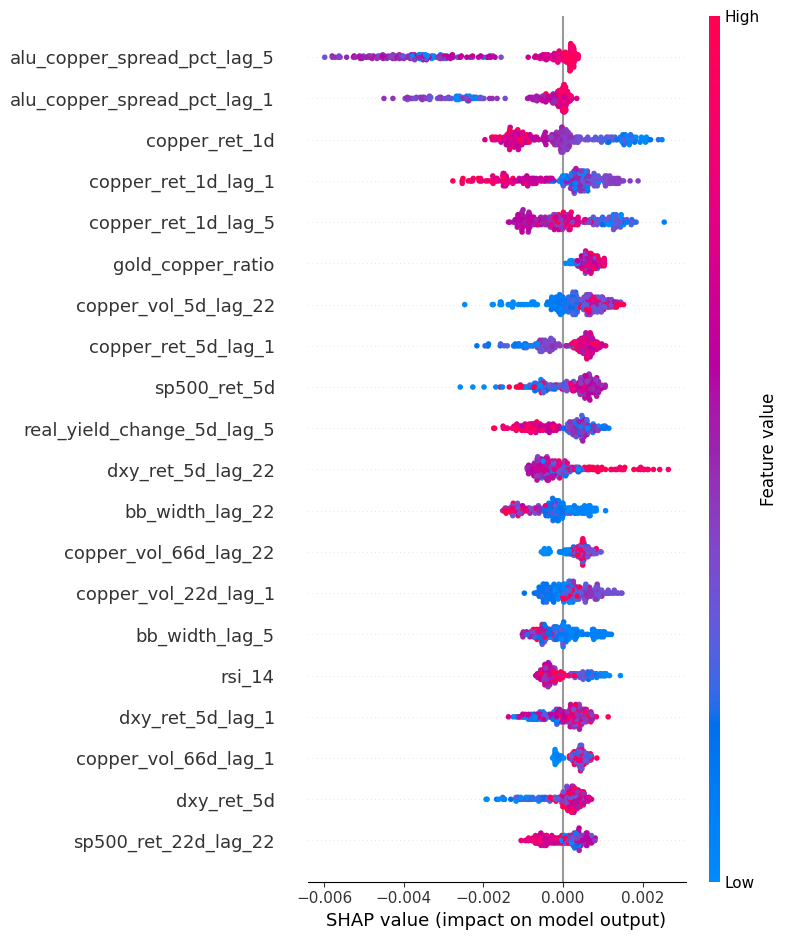

SHAP beeswarm saved.


In [27]:
try:
    import shap
    shap.initjs()

    # Refit XGBoost on pruned features for SHAP
    xgb_shap = XGBoostModel()
    xgb_shap.fit(X_dev_pruned, y_dev)
    explainer = shap.TreeExplainer(xgb_shap._model)
    shap_values = explainer.shap_values(X_hold_pruned)

    fig_shap = plot_shap_summary(shap_values, list(X_hold_pruned.columns), top_n=20)
    fig_shap.show()

    # SHAP beeswarm (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        shap.summary_plot(shap_values, X_hold_pruned, max_display=20, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(CFG['output_dir'], 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('SHAP beeswarm saved.')
    except Exception as e:
        print(f'Beeswarm plot skipped: {e}')
except Exception as e:
    print(f'SHAP analysis skipped: {e}')

In [28]:
# Top 10 features by mean |SHAP|
try:
    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X_hold_pruned.columns
    ).sort_values(ascending=False)
    print('Top 10 features by mean |SHAP|:')
    print(mean_abs_shap.head(10).to_string())
except NameError:
    print('SHAP values not available.')

Top 10 features by mean |SHAP|:
alu_copper_spread_pct_lag_5    0.002151
alu_copper_spread_pct_lag_1    0.000995
copper_ret_1d                  0.000858
copper_ret_1d_lag_1            0.000843
copper_ret_1d_lag_5            0.000707
gold_copper_ratio              0.000635
copper_vol_5d_lag_22           0.000608
copper_ret_5d_lag_1            0.000607
sp500_ret_5d                   0.000577
real_yield_change_5d_lag_5     0.000576


## 12. Interactive Plotly Visualisations

In [29]:
# Full dashboard: price history + best-model CV results
best_cv_df = cv_results[best_name]
fig_dashboard = plot_dashboard(df_aug, best_cv_df, model_name=best_name)
fig_dashboard.show()

In [30]:
# Rolling Sharpe-equivalent for the best OOS model signal
best_oos_name = oos_summary['rmse'].idxmin()
oos_best = oos_results[best_oos_name]
signal_ret_oos = np.sign(oos_best['y_pred']) * oos_best['y_true']
rolling_sharpe = (signal_ret_oos.rolling(60).mean() /
                  signal_ret_oos.rolling(60).std().replace(0, np.nan)) * np.sqrt(252 / CFG['forecast_horizon'])

import plotly.graph_objects as go
fig_sharpe = go.Figure(go.Scatter(
    x=rolling_sharpe.index, y=rolling_sharpe,
    name='Rolling Sharpe (60-day)',
    line=dict(color='#b87333'),
))
fig_sharpe.add_hline(y=0, line_width=1, line_dash='dash', line_color='grey')
fig_sharpe.update_layout(
    title=f'Rolling 60-Day Signal Sharpe — {best_oos_name}',
    template='plotly_white',
    yaxis_title='Annualised Sharpe ratio',
)
fig_sharpe.show()

## 13. Scenario Analysis

The `ScenarioEngine` takes the trained ensemble model and the most recent feature vector,
then applies additive shocks to simulate what-if conditions.

### Built-in scenarios
| Scenario | Description |
|---|---|
| `bull_strong` | DXY −5%, real yields −50 bps, IP +3 pp |
| `bear_strong` | DXY +5%, real yields +50 bps, IP −3 pp |
| `china_demand_surge` | IP +5 pp, CNY appreciation |
| `supply_disruption` | Higher vol, short-term squeeze |
| `comex_inventory_drop_40pct` | Price above 200-day average, higher vol |
| `high_inflation` | Inflation breakeven +100 bps, lower real yields |
| `us_tariff_shock` | DXY +3%, equity drawdown, higher vol |

In [31]:
# Use the latest feature vector (pruned)
latest_features = X_pruned_full.tail(1)
current_copper = float(df_aug['copper_price'].iloc[-1])

# Use the best-performing ensemble for scenarios
scenario_model = EnsembleModel([XGBoostModel(), LGBMModel()])
scenario_model.fit(X_dev_pruned, y_dev)

engine = ScenarioEngine(
    model=scenario_model,
    feature_template=latest_features,
    copper_price_current=current_copper,
    horizon=CFG['forecast_horizon'],
)
print(f'Current copper price: ${current_copper:,.0f}/t')
print(f'Baseline {CFG["forecast_horizon"]}-day forecast: ${engine.base_price:,.0f}/t')

Current copper price: $12,264/t
Baseline 1-day forecast: $12,274/t


In [32]:
# Run all pre-defined scenarios
scenario_report = engine.report()
print('\n── Scenario Report ──')
print(scenario_report.to_string())


WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
INFO | Scenario 'bull_strong': base=12274  forecast=12289  delta=+15 (0.1%)
WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
INFO | Scenario 'bear_strong': base=12274  forecast=12271  delta=-4 (-0.0%)
WARNING | Shock target 'indpro_yoy' not in feature set — skipped.
WARNING | Shock target 'cny_usd_level' not in feature set — skipped.
INFO | Scenario 'china_demand_surge': base=12274  forecast=12286  delta=+11 (0.1%)
INFO | Scenario 'supply_disruption': base=12274  forecast=12264  delta=-10 (-0.1%)
INFO | Scenario 'comex_inventory_drop_40pct': base=12274  forecast=12272  delta=-3 (-0.0%)
WARNING | Shock target 'infl_be_level' not in feature set — skipped.
INFO | Scenario 'high_inflation': base=12274  forecast=12275  delta=+1 (0.0%)
INFO | Scenario 'us_tariff_shock': base=12274  forecast=12274  delta=-0 (-0.0%)



── Scenario Report ──
                            base_price  scenario_price  delta  delta_pct
scenario                                                                
supply_disruption             12274.25        12263.98 -10.27      -0.08
bear_strong                   12274.25        12270.53  -3.72      -0.03
comex_inventory_drop_40pct    12274.25        12271.56  -2.70      -0.02
us_tariff_shock               12274.25        12273.91  -0.34      -0.00
high_inflation                12274.25        12275.28   1.03       0.01
china_demand_surge            12274.25        12285.63  11.38       0.09
bull_strong                   12274.25        12289.25  15.00       0.12


In [33]:
# Tornado chart
fig_tornado = plot_scenario_tornado(
    base_forecast=engine.base_price,
    scenario_results={row.Index: row.scenario_price for row in scenario_report.itertuples()},
)
fig_tornado.show()


In [34]:
# Sensitivity sweep: DXY shock (1-day return)
dxy_shocks = np.linspace(-0.02, 0.02, 21)  # tighter range for 1-day
sweep_dxy = engine.sweep('dxy_ret_1d', dxy_shocks.tolist(), label='DXY 1d return shock')

fig_sweep = go.Figure(go.Scatter(
    x=sweep_dxy['shock'], y=sweep_dxy['forecast_price'],
    mode='lines+markers', line=dict(color='#b87333'),
    name='Forecast price',
))
fig_sweep.add_hline(y=engine.base_price, line_dash='dash', line_color='grey',
                    annotation_text='Baseline')
fig_sweep.update_layout(
    title='Copper Price Sensitivity to DXY 1-Day Return Shock',
    xaxis_title='DXY 1d return shock (additive)',
    yaxis_title='Forecast Copper Price ($/t)',
    template='plotly_white',
)
fig_sweep.show()


In [35]:
# Custom scenario: combined geopolitical / tariff shock (1-day magnitudes)
custom_scenario = {
    'dxy_ret_1d':           0.01,   # DXY up 1% in a day
    'sp500_ret_1d':        -0.02,   # equities down 2%
    'copper_vol_5d':        0.05,   # vol spike
    'real_yield_change_1d': 0.05,   # yields up 5 bps
}
result = engine.run('geo_tariff_shock', shocks=custom_scenario)
print('Custom scenario result:')
for k, v in result.items():
    print(f'  {k}: {v}')


INFO | Scenario 'geo_tariff_shock': base=12274  forecast=12279  delta=+4 (0.0%)


Custom scenario result:
  scenario: geo_tariff_shock
  base_price: 12274.25
  scenario_price: 12278.54
  delta: 4.29
  delta_pct: 0.03


## 15. Best Model Selection & Next-Day Forecast

Select the best model from the OOS backtest (by Signal Sharpe ratio), refit it on all
available data, and produce tomorrow's price forecast with an 80% confidence interval.


In [38]:
# 1. Select best model from OOS backtest (highest Signal Sharpe)
best_name_sharpe = oos_summary['signal_sharpe'].idxmax()
best_name_rmse   = oos_summary['rmse'].idxmin()
print(f'Best by Signal Sharpe : {best_name_sharpe}')
print(f'Best by RMSE          : {best_name_rmse}')
print(f'Using: {best_name_sharpe} (Sharpe-optimised for trading)')

# Map name -> freshly instantiated model
_model_zoo = {
    'NaiveModel':    NaiveModel(),
    'LinearModel':   LinearModel(),
    'XGBoostModel':  XGBoostModel(),
    'LGBMModel':     LGBMModel(),
    'ARIMAXModel':   ARIMAXModel(exog_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d']),
    'HybridModel':   HybridModel(backbone=ARIMAXModel(exog_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d'])),
    'EnsembleModel': EnsembleModel([XGBoostModel(), LGBMModel()]),
}
if HAS_PROPHET:
    _model_zoo['ProphetModel'] = ProphetModel(regressor_cols=['dxy_level','real_yield_level','gold_copper_ratio','copper_vol_5d'])

best_model = _model_zoo.get(best_name_sharpe, LGBMModel())

# 2. Refit on ALL available pruned data (development + holdout)
best_model.fit(X_pruned_full, y_ret.reindex(X_pruned_full.index))
print(f'\nRefitted {best_name_sharpe} on {len(X_pruned_full)} rows '
      f'({X_pruned_full.index.min().date()} -> {X_pruned_full.index.max().date()})')

# 3. Forecast the next trading day
X_today   = X_pruned_full.iloc[[-1]]   # most recent available feature row
today_dt  = X_pruned_full.index[-1]
tomorrow  = today_dt + pd.offsets.BDay(1)

pred_return = float(best_model.predict(X_today)[0])
last_price  = float(df_aug['copper_price'].iloc[-1])
pred_price  = last_price * np.exp(pred_return)

# 4. 80% Confidence interval
if hasattr(best_model, 'predict_interval'):
    try:
        ci = best_model.predict_interval(X_today, alpha=CFG['ci_alpha'])
        ci_lo = last_price * np.exp(float(ci['lower'].iloc[0]))
        ci_hi = last_price * np.exp(float(ci['upper'].iloc[0]))
        ci_str = f'${ci_lo:,.0f} - ${ci_hi:,.0f}'
    except Exception:
        ci_lo, ci_hi = None, None
        ci_str = 'N/A (fallback below)'
else:
    ci_lo, ci_hi = None, None
    ci_str = 'N/A'

# Fallback: QuantileForecaster CI if model doesn't provide intervals
if ci_lo is None:
    q_fc = QuantileForecaster(alpha=CFG['ci_alpha'])
    q_fc.fit(X_pruned_full, y_ret.reindex(X_pruned_full.index))
    ci_q  = q_fc.predict(X_today)
    ci_lo = last_price * np.exp(float(ci_q['lower'].iloc[0]))
    ci_hi = last_price * np.exp(float(ci_q['upper'].iloc[0]))
    ci_str = f'${ci_lo:,.0f} - ${ci_hi:,.0f} (QuantileForecaster)'

# 5. Print result
direction = 'Bullish (+)' if pred_return > 0 else 'Bearish (-)'
print('\n' + '='*60)
print(f'  COPPER 1-DAY FORECAST  ({best_name_sharpe})')
print('='*60)
print(f'  Data as of   : {today_dt.date()}')
print(f'  Forecast date: {tomorrow.date()}')
print(f'  Current price: ${last_price:,.0f}/t')
print(f'  Pred. return : {pred_return:+.4f}  ({pred_return*100:+.2f}%)')
print(f'  Pred. price  : ${pred_price:,.0f}/t')
print(f'  80% CI       : {ci_str}')
print(f'  Signal       : {direction}')
print('='*60)


Best by Signal Sharpe : Hybrid(ARIMAX+LightGBM)
Best by RMSE          : Prophet
Using: Hybrid(ARIMAX+LightGBM) (Sharpe-optimised for trading)

Refitted Hybrid(ARIMAX+LightGBM) on 2209 rows (2015-11-09 -> 2026-04-01)

  COPPER 1-DAY FORECAST  (Hybrid(ARIMAX+LightGBM))
  Data as of   : 2026-04-01
  Forecast date: 2026-04-02
  Current price: $12,264/t
  Pred. return : -0.0085  (-0.85%)
  Pred. price  : $12,160/t
  80% CI       : $12,130 - $12,424 (QuantileForecaster)
  Signal       : Bearish (-)


## 14. Export Results

All outputs are saved to `./outputs/` as CSV and JSON for downstream use
(e.g. Power BI, Tableau, or automated reporting pipelines).

In [39]:
import json
from datetime import date

out_dir = CFG['output_dir']

# 1. Forecast with CI
forecast_df.reset_index().rename(columns={'index': 'date'}).to_csv(
    os.path.join(out_dir, 'forecast_ci.csv'), index=False
)

# 2. OOS backtest results
for name, df_oos in oos_results.items():
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    df_oos.to_csv(os.path.join(out_dir, f'oos_{safe_name}.csv'))

# 3. Model comparison summary
oos_summary.to_csv(os.path.join(out_dir, 'model_comparison.csv'))

# 4. Scenario report
scenario_report.to_csv(os.path.join(out_dir, 'scenario_report.csv'))

# 5. Cointegration results
coint_df.to_csv(os.path.join(out_dir, 'cointegration_results.csv'))

# 6. JSON summary (for APIs / dashboards)
summary_json = {
    'generated_at':      date.today().isoformat(),
    'current_price':     round(current_copper, 2),
    'baseline_forecast': round(engine.base_price, 2),
    'horizon_days':      CFG['forecast_horizon'],
    'best_model':        best_oos_name,
    'oos_metrics':       oos_metrics[best_oos_name],
    'scenarios':         scenario_report.reset_index().to_dict(orient='records'),
}
with open(os.path.join(out_dir, 'forecast_summary.json'), 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'All outputs saved to {out_dir}/')
print('Files:', os.listdir(out_dir))

All outputs saved to ./outputs_1d/
Files: ['cointegration_results.csv', 'forecast_ci.csv', 'forecast_summary.json', 'model_comparison.csv', 'oos_ARIMAX.csv', 'oos_EnsembleXGBoost+LightGBM.csv', 'oos_HybridARIMAX+LightGBM.csv', 'oos_LightGBM.csv', 'oos_Linear_Ridge.csv', 'oos_Naive_RW.csv', 'oos_Prophet.csv', 'oos_XGBoost.csv', 'scenario_report.csv', 'shap_beeswarm.png']


---
## Summary

| Step | Completed |
|---|---|
| Data ingestion (yfinance + FRED + COT) | ✅ |
| Cointegration analysis (Engle-Granger + ECT features) | ✅ |
| Regime detection (3-state HMM) | ✅ |
| Feature engineering (price, cross-asset, macro, calendar, COT, structural) | ✅ |
| Model training: Naive, Ridge, XGBoost, LightGBM, ARIMAX, Prophet, Hybrid, Ensembles | ✅ |
| Feature pruning (SHAP-based bottom 20% removal) | ✅ |
| Optuna hyper-parameter tuning | ✅ |
| Walk-forward cross-validation (with signal Sharpe) | ✅ |
| Out-of-sample backtest (last 12 months) | ✅ |
| Forecast with 80% CI (quantile + ARIMAX intervals) | ✅ |
| SHAP explainability | ✅ |
| Interactive Plotly visualisations | ✅ |
| Scenario analysis | ✅ |
| JSON / CSV export | ✅ |